# Linear hyperbolic systems: characteristic variables

The diagonal system $u_t=u_x$, $v_t=-v_x$ demonstrates canonical matrix extraction, diagonalizability, characteristic propagation, and vector residual verification.

**Tutorial contract.** This notebook derives the mathematics, asks PDESolve how it recognizes/plans the problem, executes the solver, independently checks the returned mathematics where appropriate, visualizes the solution or its structure, and ends with runnable variations plus exercises.

In [1]:
from pathlib import Path
import sys

# Make a source checkout importable without requiring an editable install.
root = Path.cwd().resolve()
for candidate in [root, *root.parents]:
    if (candidate / "pdesolve").is_dir():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the pdesolve source tree")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pdesolve as pds
from IPython.display import display

sp.init_printing()
print("PDESolve source:", ROOT)
print("SymPy:", sp.__version__)

PDESolve source: /mnt/data/pdesolve_doc22SymPy: 1.14.0

In [2]:
def show_plan(problem, n=6):
    """Display recognizer output and the highest-ranked canonical plan steps."""
    rec = pds.recognize_canonical_problem(problem)
    plan = pds.plan_canonical_problem(problem)
    print("Recognition:", rec)
    print("Top plan steps:")
    for step in plan.steps[:n]:
        print(f"  {step.method:42s} score={step.score}")
    return rec, plan


def rhs_of(solution):
    """Extract the RHS of an Eq result, or return an expression unchanged."""
    return solution.rhs if isinstance(solution, sp.Equality) else solution


def residual(eq, dependent, candidate):
    """Classical residual after replacing the dependent function by candidate."""
    expr = eq.lhs - eq.rhs if isinstance(eq, sp.Equality) else eq
    return sp.simplify(expr.subs(dependent, candidate).doit())

## 1. DerivationWrite $U=(u,v)^T$. The equations are already diagonal, so the characteristic speeds are opposite. The first component satisfies $u_t-u_x=0$ and therefore propagates as $f(x+t)$; the second satisfies $v_t+v_x=0$ and propagates as $g(x-t)$. With $f=\sin$ and $g=\cos$,$$u=\sin(x+t),\qquad v=\cos(x-t).$$

In [3]:
x,t=sp.symbols("x t", real=True)
u,v=sp.Function("u"),sp.Function("v")
eqs=[sp.Eq(sp.diff(u(x,t),t),sp.diff(u(x,t),x)),sp.Eq(sp.diff(v(x,t),t),-sp.diff(v(x,t),x))]
ics=[sp.Eq(u(x,0),sp.sin(x)),sp.Eq(v(x,0),sp.cos(x))]
canonical=pds.extract_canonical_linear_system_form(eqs,(u,v),(x,t))
print("Diagonalizable:",canonical.diagonalizable)
print(canonical)

Diagonalizable: TrueCanonicalLinearSystemPDE(equations=(Eq(Derivative(u(x, t), t), Derivative(u(x, t), x)), Eq(Derivative(v(x, t), t), -Derivative(v(x, t), x))), variables=(x, t), unknowns=(u, v), coeff_matrix=Matrix([[1,  0],[0, -1]]), forcing=Matrix([[0],[0]]), variable_coefficient=False, diagonalizable=True, transform_matrix=Matrix([[0, 1],[1, 0]]), diagonal_matrix=Matrix([[-1, 0],[ 0, 1]]))

In [4]:
result=pds.solve_hyperbolic_system(eqs,ics,(u,v),vars=(x,t))
print(type(result).__name__, result.metadata["solver"])
print(result.solution)

HyperbolicSystemResult diagonalization{u(x, t): sin(t + x), v(x, t): cos(t - x)}

In [5]:
usol=result.solution[u(x,t)]; vsol=result.solution[v(x,t)]
assert sp.simplify(sp.diff(usol,t)-sp.diff(usol,x))==0
assert sp.simplify(sp.diff(vsol,t)+sp.diff(vsol,x))==0
assert sp.simplify(usol.subs(t,0)-sp.sin(x))==0
assert sp.simplify(vsol.subs(t,0)-sp.cos(x))==0
print("All component PDE and initial residuals are zero.")

All component PDE and initial residuals are zero.

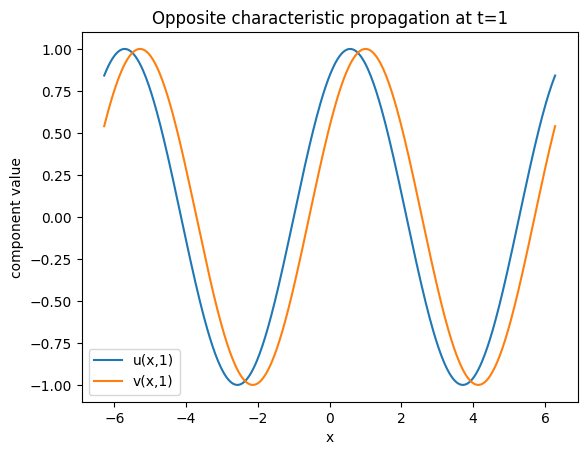

In [6]:
xx=np.linspace(-2*np.pi,2*np.pi,500)
fig,ax=plt.subplots(); ax.plot(xx,np.sin(xx+1),label="u(x,1)"); ax.plot(xx,np.cos(xx-1),label="v(x,1)")
ax.set_xlabel("x"); ax.set_ylabel("component value"); ax.set_title("Opposite characteristic propagation at t=1"); ax.legend(); plt.show()

## 3. Variation and exercisesChange the initial profiles below. Then: (1) construct a constant non-diagonal $2\times2$ matrix with real eigenvectors; (2) predict its characteristic variables; (3) identify what fails when the system is not diagonalizable over the desired field.

In [7]:
ics2=[sp.Eq(u(x,0),sp.exp(-x**2)),sp.Eq(v(x,0),sp.sin(2*x))]
r2=pds.solve_hyperbolic_system(eqs,ics2,(u,v),vars=(x,t))
print(r2.details["solver"]); print(r2.solution)

diagonalization{u(x, t): exp(-(t + x)**2), v(x, t): -sin(2*t - 2*x)}